# COGS 45 — Week 1 Lab: Supervised Learning with Feedforward Neural Networks

For this homework, we train a feedforward neural network (a **multi-layer perceptron**, or MLP) to classify handwritten MNIST digits. We evaluate how well it generalizes when certain classes of digits (e.g., odd ones) are held out of the training dataset.

We also evaluate the errors the network makes using a **confusion matrix** — a matrix showing, for each true digit class, what the network predicted. For example: when the true image was a 5, what did the network most often guess?


In [2]:
# ============================================================
# IMPORTS
# ============================================================

# numpy: the standard library for numerical computing in Python.
# We'll use it for array operations when analyzing predictions.
import numpy as np

# torch (PyTorch): the deep learning framework we're using.
# It provides tools for building, training, and evaluating neural networks.
import torch
import torch.nn as nn                  # nn contains neural network building blocks (layers, loss functions)
import torch.nn.functional as F        # F contains functions like activation functions, used in forward passes
import torch.utils
import torch.distributions
from torch.utils.data import Subset, DataLoader  # Subset: grab a slice of a dataset; DataLoader: iterate in batches

# torchvision: provides standard datasets (like MNIST) and image transforms
import torchvision

# sklearn: we use this for computing and displaying confusion matrices
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# matplotlib: for plotting
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200  # make plots high-resolution

# We'll use CPU here. If you have a GPU, you could set device = 'cuda'.
device = 'cpu'


## Step 1: Prepare the Data

MNIST is a classic dataset of 70,000 handwritten digits (0–9), split into 60,000 training and 10,000 test images. Each image is 28×28 pixels, grayscale.

Our goal is to train ONLY on even digits (0, 2, 4, 6, 8), then test:
- **(a)** on held-out even digits the network never trained on (but same categories)
- **(b)** on odd digits (1, 3, 5, 7, 9) — entirely new categories the network has never seen

This lets us ask: can the network generalize to new *examples* of known categories? And can it generalize to entirely *unknown* categories?


In [3]:
# ============================================================
# LOAD THE FULL MNIST DATASET
# ============================================================

# train=True  → the 60,000 image training split
# train=False → the 10,000 image test split
# ToTensor() converts each image from a PIL image to a PyTorch tensor
#   with pixel values scaled to [0, 1]

mnist_trainset = torchvision.datasets.MNIST(
    './data', train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True
)

mnist_testset = torchvision.datasets.MNIST(
    './data', train=False,
    transform=torchvision.transforms.ToTensor(),
    download=True
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.51MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.50MB/s]


In [4]:
# ============================================================
# SPLIT INTO EVEN AND ODD SUBSETS
# ============================================================
# We need to carve the full dataset into pieces:
#   - Even digits from the TRAINING set → what the network learns from
#   - Even digits from the TEST set     → generalization test (a): new examples, same categories
#   - Odd digits from the TEST set      → generalization test (b): entirely new categories
#
# We do this by finding the indices of even/odd examples and creating Subsets.

even_digits = [0, 2, 4, 6, 8]
odd_digits = [1, 3, 5, 7, 9]

# --- Training data: even digits only ---
# Loop through every example in the training set. If the label is even, save its index.
even_train_indices = [i for i, (_, label) in enumerate(mnist_trainset) if label in even_digits]
even_train_subset = Subset(mnist_trainset, even_train_indices)

# DataLoader wraps the dataset so we can iterate in batches.
#   batch_size=64: process 64 images at a time (faster + better gradient estimates than 1 at a time)
#   shuffle=True:  randomize order each epoch (prevents the network from memorizing sequence)
even_train_loader = DataLoader(even_train_subset, batch_size=64, shuffle=True)

# --- Test data: even digits (for test a) ---
even_test_indices = [i for i, (_, label) in enumerate(mnist_testset) if label in even_digits]
even_test_subset = Subset(mnist_testset, even_test_indices)
even_test_loader = DataLoader(even_test_subset, batch_size=64, shuffle=False)

# --- Test data: odd digits (for test b) ---
odd_test_indices = [i for i, (_, label) in enumerate(mnist_testset) if label in odd_digits]
odd_test_subset = Subset(mnist_testset, odd_test_indices)
odd_test_loader = DataLoader(odd_test_subset, batch_size=64, shuffle=False)

# Sanity check: how many examples in each split?
print(f"Even training examples: {len(even_train_indices)}")
print(f"Even test examples:     {len(even_test_indices)}")
print(f"Odd test examples:      {len(odd_test_indices)}")


Even training examples: 29492
Even test examples:     4926
Odd test examples:      5074


## Step 2: Define the Network Architecture

A multi-layer perceptron (MLP) is one of the simplest feedforward neural networks. "Feedforward" means information flows in one direction: input → hidden layers → output. There are no loops or recurrence.

**Our architecture:**
- **Input layer:** 784 nodes (28×28 pixels, flattened into a vector)
- **Hidden layer 1:** 50 nodes with ReLU activation
- **Hidden layer 2:** 25 nodes with ReLU activation
- **Output layer:** 10 nodes (one per digit class, 0–9)

**ReLU** (Rectified Linear Unit) is a simple activation function: ReLU(x) = max(0, x). It introduces nonlinearity, which is what allows the network to learn complex mappings. Without it, stacking linear layers would just collapse into a single linear transformation.

The output layer has 10 nodes because there are 10 possible digit classes. The network outputs a score (called a "logit") for each class. The highest score is the network's prediction. During training, we convert these to probabilities using the cross-entropy loss function.

**Note:** even though we only train on 5 even digit categories, the output layer still has 10 nodes. The network *could* output any digit 0–9 — it just never receives training signal for the odd classes. This is important for understanding the confusion matrix later.


In [6]:
# ============================================================
# DEFINE THE MLP
# ============================================================

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # Layer 1: takes the 784-pixel input, projects to 50 hidden units
        self.linear1 = nn.Linear(28*28, 50)

        # Layer 2: takes 50 hidden units, projects to 25 hidden units
        self.linear2 = nn.Linear(50, 25)

        # Output layer: takes 25 hidden units, projects to 10 class scores
        self.final = nn.Linear(25, 10)

        # Activation function: ReLU introduces nonlinearity between layers
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        The forward pass: defines how data flows through the network.
        x starts as a flattened image (784 values), and we get back 10 class scores.
        """
        x = self.relu(self.linear1(x))   # Input → 50 hidden units → ReLU
        x = self.relu(self.linear2(x))   # 50 → 25 hidden units → ReLU
        x = self.final(x)                # 25 → 10 output scores (no activation here;
                                          #   cross-entropy loss handles the softmax)
        return x


## Step 3: Train the Network

Training a neural network means adjusting its weights to minimize a loss function.

**Loss function — Cross-Entropy:** Cross-entropy measures how far the network's predicted probability distribution is from the true label. If the network puts high probability on the correct class, loss is low. If it spreads probability across wrong classes, loss is high.

**Optimizer — Adam:** Adam is a variant of stochastic gradient descent (SGD) that adapts the learning rate for each parameter. The learning rate (lr=0.001) controls how big each weight update is. Too high → unstable training. Too low → slow convergence.

**Training loop:** For each epoch (one full pass through the training data):
1. Grab a batch of 64 images and their labels
2. Flatten each 28×28 image into a 784-dimensional vector
3. Pass it through the network (forward pass) to get predictions
4. Compute the loss (how wrong were we?)
5. Backpropagate the loss to compute gradients (how should each weight change?)
6. Update the weights using the optimizer
7. Track loss and accuracy so we can plot them later


In [7]:
# ============================================================
# TRAINING LOOP
# ============================================================

net = Net()                                          # Initialize a fresh network with random weights
Xent = nn.CrossEntropyLoss()                         # Cross-entropy loss function
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)  # Adam optimizer, learning rate = 0.001

# We'll track these for plotting
train_losses = []       # Loss at every single batch update
train_accuracies = []   # Accuracy at the end of each epoch

epochs = 5  # Number of full passes through the training data
for epoch in range(epochs):
    epoch_correct = 0   # Count correct predictions this epoch
    epoch_total = 0     # Count total predictions this epoch

    for data in even_train_loader:
        x, y = data     # x = batch of images, y = batch of true labels

        # --- Forward pass ---
        optimizer.zero_grad()              # Reset gradients from the previous step
        output = net(x.view(-1, 28*28))    # Flatten images (batch, 1, 28, 28) → (batch, 784)
                                            #   then pass through the network

        # --- Compute loss ---
        loss = Xent(output, y)             # Compare network output to true labels

        # --- Backward pass ---
        loss.backward()                    # Compute gradient of loss w.r.t. every weight
        optimizer.step()                   # Update weights in the direction that reduces loss

        # --- Track metrics ---
        train_losses.append(loss.item())   # .item() extracts the number from the tensor
        preds = output.argmax(dim=1)       # The predicted class = whichever output node is highest
        epoch_correct += (preds == y).sum().item()
        epoch_total += y.size(0)

    # Compute accuracy for this epoch
    epoch_acc = epoch_correct / epoch_total
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Train Acc: {epoch_acc:.4f}")


Epoch 1, Loss: 0.1005, Train Acc: 0.9215
Epoch 2, Loss: 0.1448, Train Acc: 0.9694
Epoch 3, Loss: 0.1715, Train Acc: 0.9764
Epoch 4, Loss: 0.0617, Train Acc: 0.9809
Epoch 5, Loss: 0.0368, Train Acc: 0.9838


## Step 4: Evaluate on Held-Out Data

Now we test the trained network on data it has never seen during training.

**Test (a) — Unseen even digits:** These are new *examples* of the same categories (0, 2, 4, 6, 8) from the test split. The network has seen other 4s and 8s, just not these specific ones. This tests standard generalization: can the network recognize digits it hasn't memorized?

**Test (b) — Odd digits:** These are entirely new *categories* (1, 3, 5, 7, 9) that never appeared in training.

We use `torch.no_grad()` during evaluation because we don't need gradients — we're not updating any weights, just measuring performance.


In [ ]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader):
    """
    Run the model on every example in the loader.
    Returns:
      - all_preds:  numpy array of predicted labels
      - all_labels: numpy array of true labels
      - accuracy:   fraction of predictions that are correct
    """
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No gradient computation needed for evaluation
        for x, y in loader:
            output = model(x.view(-1, 28*28))   # Forward pass (same as training, but no weight updates)
            preds = output.argmax(dim=1)         # Predicted class = highest-scoring output node
            all_preds.extend(preds.numpy())
            all_labels.extend(y.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy = (all_preds == all_labels).mean()
    return all_preds, all_labels, accuracy

# --- Run evaluation on both test sets ---
even_preds, even_labels, even_acc = evaluate(net, even_test_loader)
odd_preds, odd_labels, odd_acc = evaluate(net, odd_test_loader)

print(f"Test accuracy on unseen EVEN digits: {even_acc:.4f}")
print(f"Test accuracy on ODD digits:         {odd_acc:.4f}")


Test accuracy on unseen EVEN digits: 0.9797
Test accuracy on ODD digits:         0.0000


## Step 5: Visualize the Results

We plot four things:

1. **Training loss over update steps** — shows whether the network is learning (loss should decrease).
2. **Training accuracy over epochs** — shows classification performance on training data over time.
3. **Confusion matrix for test (a): even digits**
4. **Confusion matrix for test (b): odd digits**

he pattern of "errors" reveals what visual features the network has learned and/or what **biases it has.** For example, if 9s get classified as 4s, that suggests the network has learned features (like a closed loop at the top) that are shared between those digits.

**How to read a confusion matrix:**
- **Rows** = true labels (what the digit actually is)
- **Columns** = predicted labels (what the network guessed)
- **Diagonal** = correct classifications
- **Off-diagonal** = errors (and the pattern tells you which digits the network confuses)


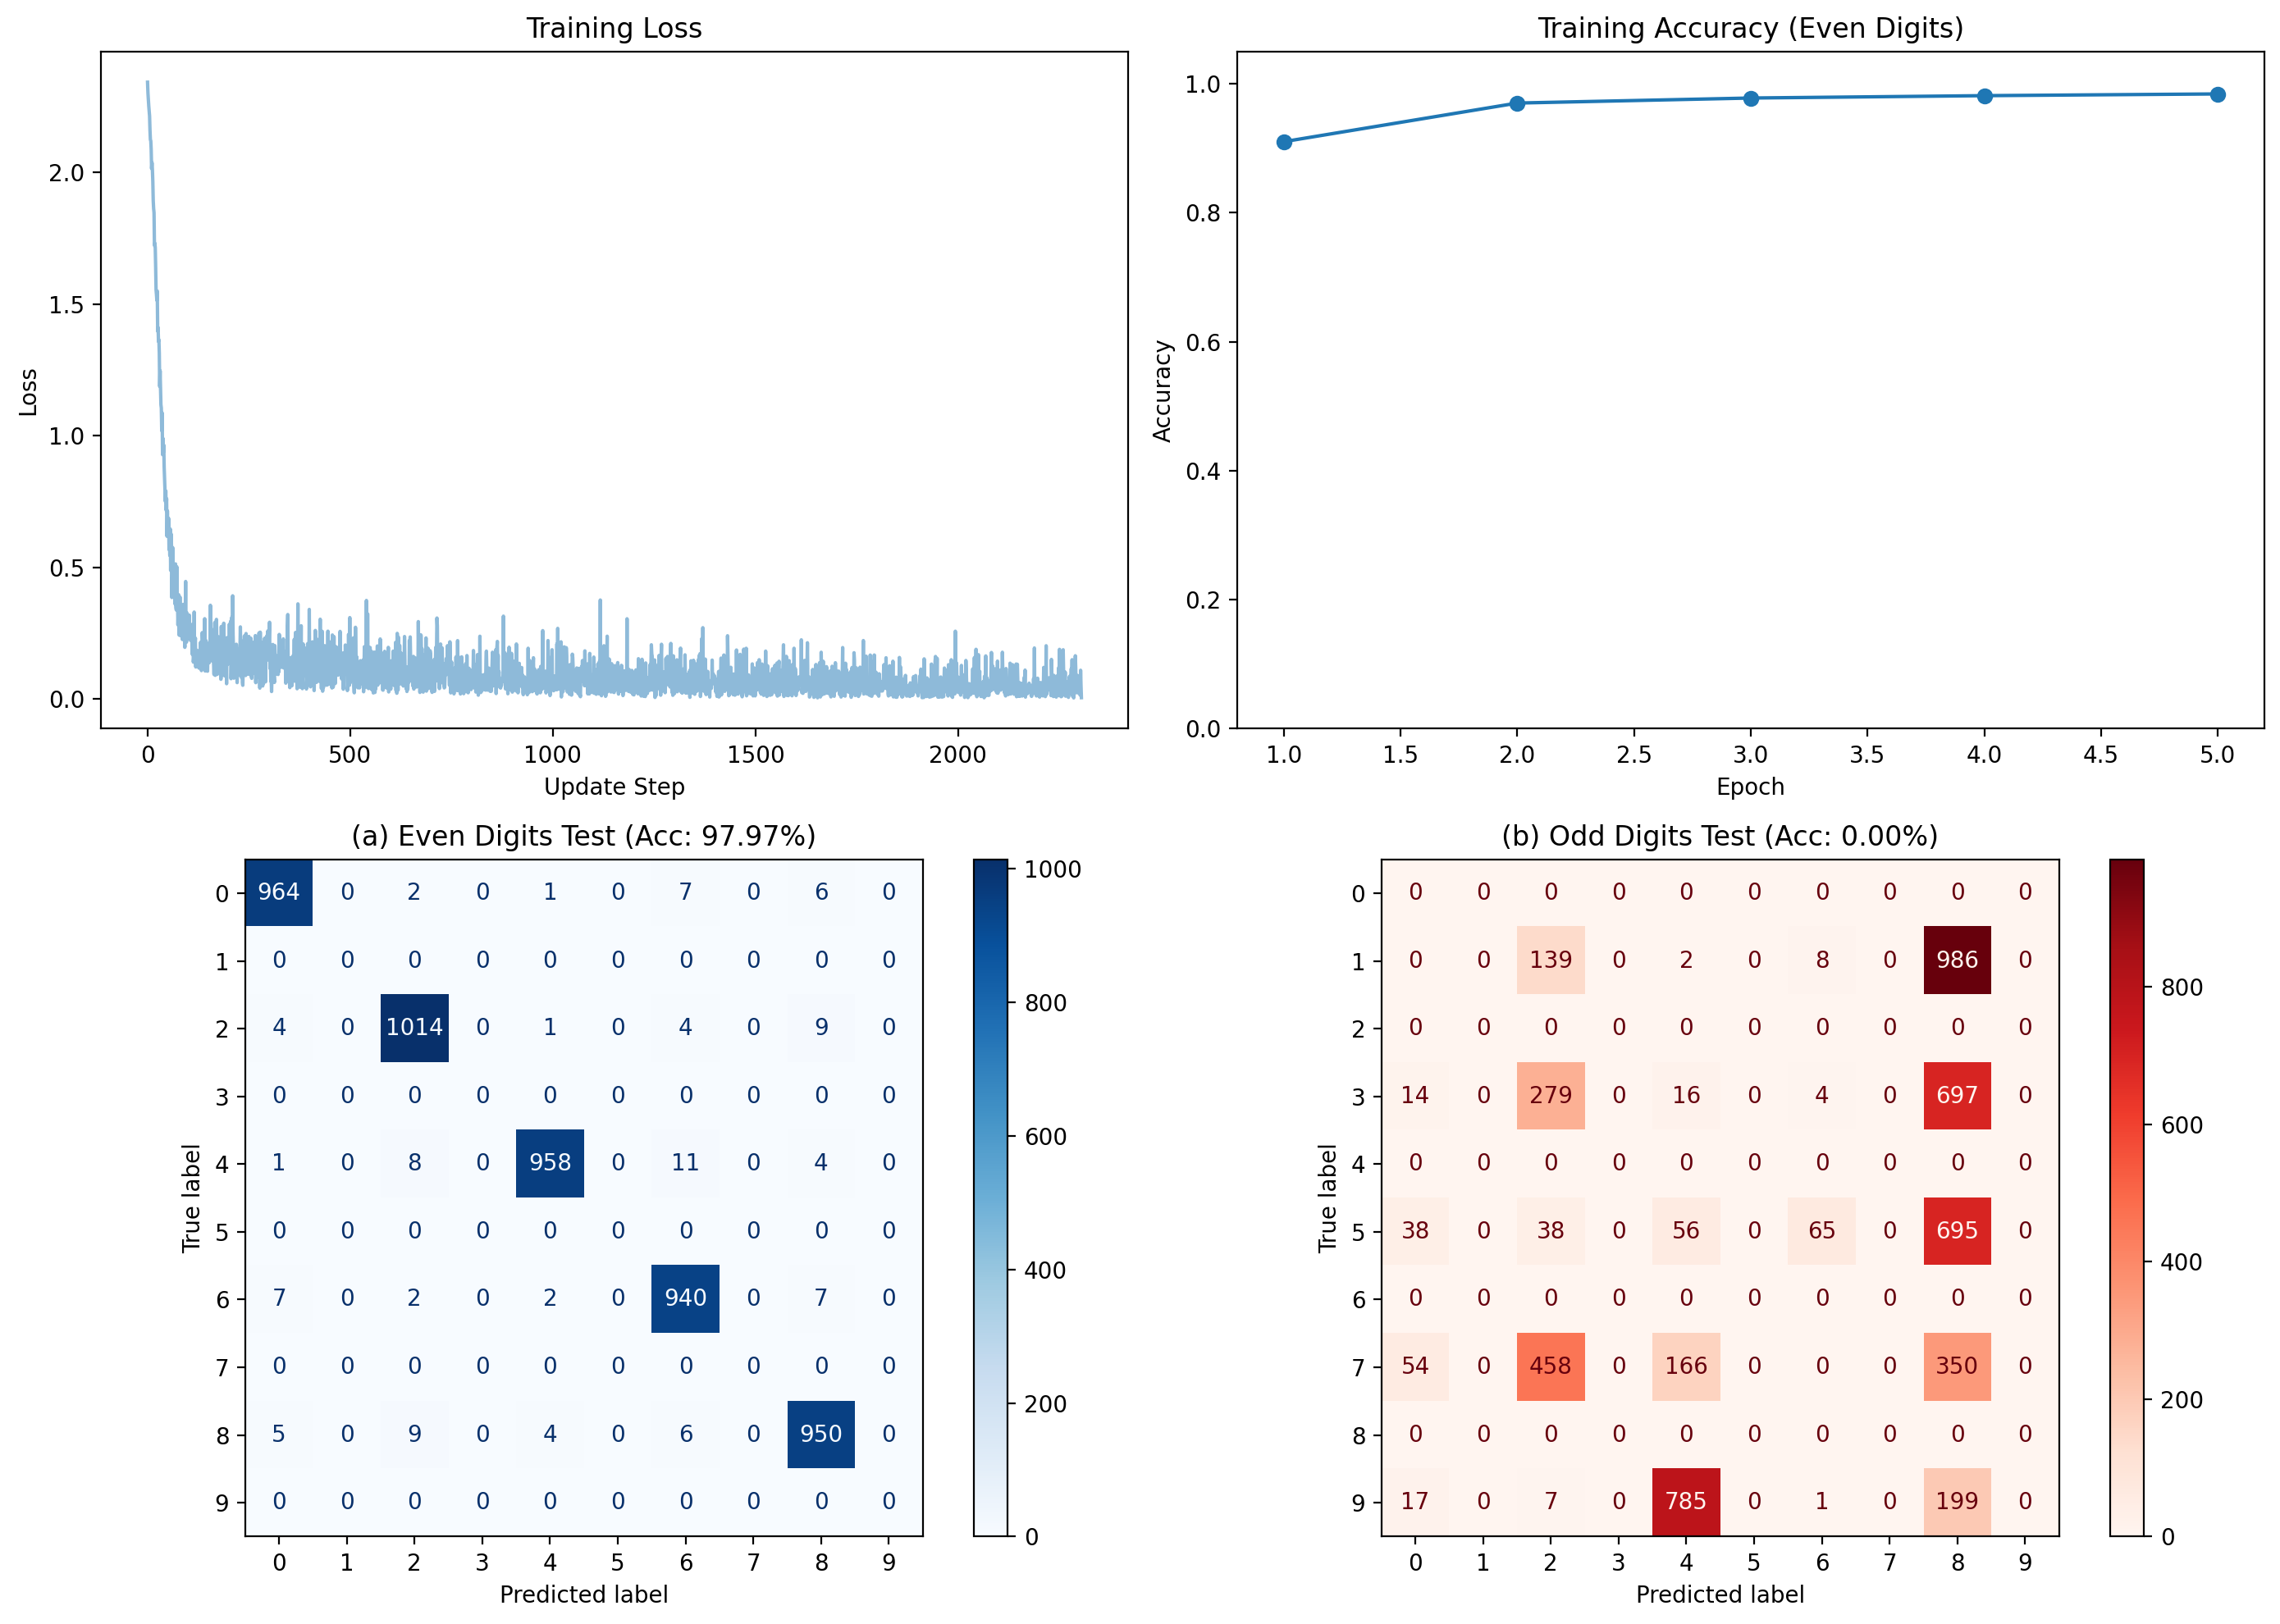

In [ ]:
# ============================================================
# PLOTTING
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Top left: Training loss over every batch update ---
# You should see this decrease over time as the network learns.
# It will be noisy because each point is a single batch of 64 images.
axes[0, 0].plot(train_losses, alpha=0.5)
axes[0, 0].set_xlabel('Update Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')

# --- Top right: Training accuracy at the end of each epoch ---
# This should climb toward high accuracy on even digits.
axes[0, 1].plot(range(1, epochs+1), train_accuracies, marker='o')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training Accuracy (Even Digits)')
axes[0, 1].set_ylim(0, 1.05)

# --- Bottom left: Confusion matrix for held-out even digits ---
# This should be mostly diagonal — the network knows these categories.
even_cm = confusion_matrix(even_labels, even_preds, labels=range(10))
ConfusionMatrixDisplay(even_cm, display_labels=range(10)).plot(ax=axes[1, 0], cmap='Blues')
axes[1, 0].set_title(f'(a) Even Digits Test (Acc: {even_acc:.2%})')

# --- Bottom right: Confusion matrix for odd digits ---
# This is where it gets interesting! The network has never seen odd digits,
# so every odd digit gets mapped to some even digit category.
# Look at which even digits each odd digit gets confused with — this tells
# you what visual features the network has learned to rely on.
odd_cm = confusion_matrix(odd_labels, odd_preds, labels=range(10))
ConfusionMatrixDisplay(odd_cm, display_labels=range(10)).plot(ax=axes[1, 1], cmap='Reds')
axes[1, 1].set_title(f'(b) Odd Digits Test (Acc: {odd_acc:.2%})')

plt.tight_layout()
plt.show()
